In [1]:
## test1
from bigrams import BIGRAM_BAG

print(len(BIGRAM_BAG))
print(BIGRAM_BAG[:5])

40
['th', 'he', 'in', 'er', 'an']


In [2]:
## test2
from text_processing import count_tracked_bigrams, counts_to_vector

sentence = "The queen quickly quit the quiet quiz"
counts = count_tracked_bigrams(sentence)
print(counts)

vector = counts_to_vector(counts)
print(vector)

Counter({'th': 2, 'he': 2, 'en': 1, 'ic': 1, 'it': 1})
[2. 2. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [3]:
## test 3
from typing_env import TypingEnv

env = TypingEnv()
env.reset()

for _ in range(5):
    state, reward, _, _ = env.step(0)
    print("Reward:", reward)

Reward: 0.11450549169928152
Reward: 0.0687546360691354
Reward: 0.021748499436842317
Reward: -0.05159416816220344
Reward: -0.10855393080910306


In [4]:
## test 4
env.sample_sentence(0,1)

'thunder and lightning thrilled the three children together'

### we can see the skill growing, as we ran 5 iterations, and rewards are positive.

In [5]:
## test 5
env = TypingEnv()
state = env.reset()

for _ in range(5):
    action = 0  # same bigram
    state, reward, _, _ = env.step(action)
    print("Reward:", reward)
    print("Skill:", env.k[0])

Reward: 0.12146161439490329
Skill: 0.28798282654924645
Reward: 0.02989436587362454
Skill: 0.3166315123806417
Reward: -0.009331681594856922
Skill: 0.3900974299004841
Reward: -0.050847659068497864
Skill: 0.4494382099550625
Reward: -0.08786517136118038
Skill: 0.5086266679975524


### Forgetting Curve

[np.float64(0.98), np.float64(0.9799737635735533), np.float64(0.98), np.float64(0.98), np.float64(0.9799737635735533), np.float64(0.9799267015545504), np.float64(0.9798622809314729), np.float64(0.9797828922673703), np.float64(0.9796902685251667), np.float64(0.9795857120557456), np.float64(0.9794702282133221), np.float64(0.9793446090616753), np.float64(0.9792094884323387), np.float64(0.9790653795875834), np.float64(0.9789127018284431), np.float64(0.9787517998069513), np.float64(0.9785829578679904), np.float64(0.9798909271487365), np.float64(0.9798909271487365), np.float64(0.9798645476381977), np.float64(0.979817228959765), np.float64(0.9797524570096354), np.float64(0.9796726353881352), np.float64(0.9795795065091488), np.float64(0.9794743798261158), np.float64(0.9793582661760939), np.float64(0.979231961942495), np.float64(0.9790961044135431), np.float64(0.9789512096506584), np.float64(0.9787976992415924), np.float64(0.9786359197179876), np.float64(0.978466156975442), np.float64(0.9782886

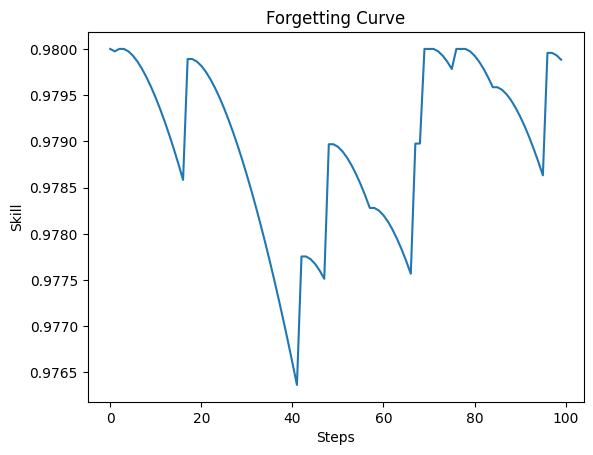

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing_env import TypingEnv


env = TypingEnv()
state = env.reset()

target_bigram = 39
difficulty = 3
action = target_bigram * env.L + difficulty

# forgetting curve experiment
env.reset()

learning_steps = 100
forget_steps = 100

forget_curve = []

# learn first
for step in range(learning_steps):
    state, reward, done, _ = env.step(action)

# stop practicing target bigram
for step in range(forget_steps):
    random_action = np.random.randint(0, env.K * env.L)
    state, reward, done, _ = env.step(31)
    forget_curve.append(env.k[target_bigram])

print(forget_curve)

plt.plot(forget_curve)
plt.title("Forgetting Curve")
plt.xlabel("Steps")
plt.ylabel("Skill")

plt.show()

In [7]:
import pandas as pd
df = pd.read_csv("typing_dataset.csv")
df.head()


,sentence,target_bigram,difficulty
0,the thin cat sat on the mat,th,0
1,this path has the moth on it,th,0
2,that cloth has both the moths,th,0
3,the bath with the thick cloth,th,0
4,both the teeth and the cloth,th,0


In [8]:

for i in range(20):
    j = i // 20
    if(i==0):
        print(f"for bigram {BIGRAM_BAG[j]}")
    sentence = df['sentence'][i]
    print(count_tracked_bigrams(sentence)[BIGRAM_BAG[j]])
    

for bigram th
3
4
5
6
5
5
5
5
5
5
5
5
5
6
5
5
5
5
5
5


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from typing_env import TypingEnv

In [10]:
def run_random_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    K = env.K
    L = env.L
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = np.random.randint(0, K * L)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])  # final skill
        
    return all_rewards, all_skills

In [11]:
def select_action(env):
    
    scores = env.k - 0.1 * env.t
    weakest_bigram = np.argmin(scores)
    
    skill = env.k[weakest_bigram]
    
    if skill < 0.3:
        difficulty = 0
    elif skill < 0.5:
        difficulty = 1
    elif skill < 0.7:
        difficulty = 2
    elif skill < 0.85:
        difficulty = 3
    else:
        difficulty = 4
    
    return weakest_bigram * env.L + difficulty

In [12]:
def run_rule_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = select_action(env)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])
        
    return all_rewards, all_skills

In [13]:
random_rewards, random_skills = run_random_agent()
rule_rewards, rule_skills = run_rule_agent()

In [14]:
print("Random avg skill:", np.mean(random_skills))
print("Rule avg skill:", np.mean(rule_skills))

print("Random avg reward:", np.mean(random_rewards))
print("Rule avg reward:", np.mean(rule_rewards))

Random avg skill: 0.7793601413189507
Rule avg skill: 0.5090605874680894
Random avg reward: 0.17443560815366252
Rule avg reward: -0.1764961931347064


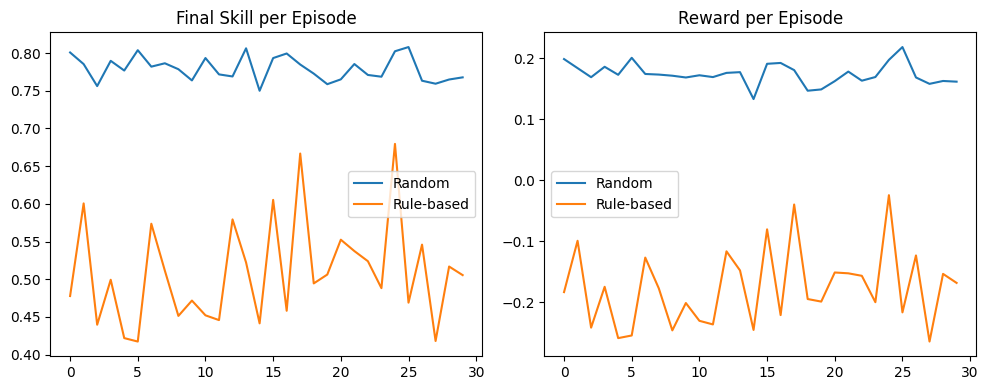

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(random_skills, label="Random")
plt.plot(rule_skills, label="Rule-based")
plt.title("Final Skill per Episode")
plt.legend()

plt.subplot(1,2,2)
plt.plot(random_rewards, label="Random")
plt.plot(rule_rewards, label="Rule-based")
plt.title("Reward per Episode")
plt.legend()

plt.tight_layout()
plt.show()

## test for q_learning agent

In [16]:
from q_learning import QLearningAgent

agent = QLearningAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Episode 10 | Reward: 0.2579 | Skill: 0.9250 | Epsilon: 0.980


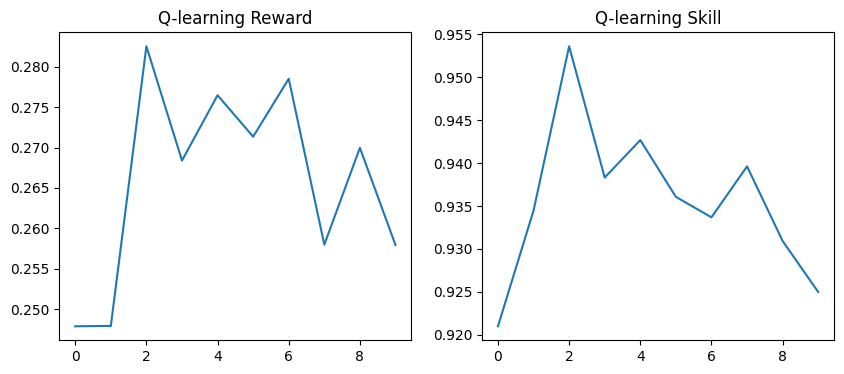

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(rewards)
plt.title("Q-learning Reward")

plt.subplot(1,2,2)
plt.plot(skills)
plt.title("Q-learning Skill")

plt.show()

## test for DQN agent

In [18]:
from dqn_agent import DQNAgent

agent = DQNAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Ep 1 | Reward: 0.2824 | Skill: 0.9450 | Eps: 0.995
Ep 2 | Reward: 0.2520 | Skill: 0.9201 | Eps: 0.990
Ep 3 | Reward: 0.2598 | Skill: 0.9224 | Eps: 0.985
Ep 4 | Reward: 0.2601 | Skill: 0.9336 | Eps: 0.980
Ep 5 | Reward: 0.2746 | Skill: 0.9491 | Eps: 0.975
Ep 6 | Reward: 0.2806 | Skill: 0.9518 | Eps: 0.970
Ep 7 | Reward: 0.2740 | Skill: 0.9489 | Eps: 0.966
Ep 8 | Reward: 0.2809 | Skill: 0.9497 | Eps: 0.961
Ep 9 | Reward: 0.2493 | Skill: 0.9222 | Eps: 0.956
Ep 10 | Reward: 0.2443 | Skill: 0.9224 | Eps: 0.951


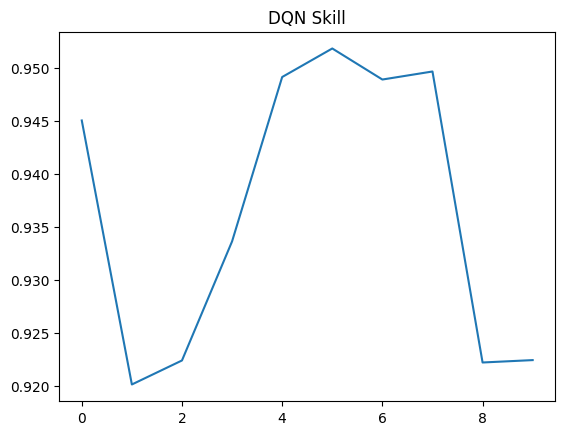

In [19]:
import matplotlib.pyplot as plt

plt.plot(skills)
plt.title("DQN Skill")
plt.show()